In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import matplotlib.dates as mdates
import os

from datetime import date
from dateutil.relativedelta import relativedelta

In [3]:
folder_path = 'C:/Users/Alfredo/Downloads/store-sales-time-series-forecasting/'
datasets = {}

for file in os.listdir(folder_path):
    if(file.endswith('.csv')):
        name = os.path.splitext(file)[0]
        file_path = os.path.join(folder_path, file)
        datasets[name] = pd.read_csv(file_path)

In [5]:
for i in datasets.keys():
    print(f'<li>{i}</li>')

<li>holidays_events</li>
<li>oil</li>
<li>sample_submission</li>
<li>stores</li>
<li>test</li>
<li>train</li>
<li>transactions</li>


It looks like we have the following datasets:
<ul>
    <li>holidays_events</li>
    <li>oil</li>
    <li>sample_submission</li>
    <li>stores</li>
    <li>test</li>
    <li>train</li>
    <li>transactions</li>
</ul>

First we inspec the holiday events, it includes 350 holidays with no missing dates. Using the dataset analysis we can see:
<ul>
    <li>there are 6 types of events with holiday being the most observed</li>
    <li>They are mostly distributed between national and local with a few regional</li>
    <li>We have a list of name of the events and cities where this applies. The city might apply</li>
    <li>We have most of them as transferred</li>
</ul>

Next we have the oil prices with missing values. even tho we cant identify the reason for these missing values, we can see the data prior to the missing value and after is not changing too drastically which means we can fill them backwards.

Third we have the sample submission, this can be ignored. 

Fourth we have the stores. This includes 54 stores with no missing values the columns we have are: 
<ul>
    <li>store_nbr</li>
    <li>city</li>
    <li>state</li>
    <li>type</li>
    <li>cluster: the most interesting one, showins us clusters from 1 to 17 with as many as 12 stores per cluster</li>
</ul>

5th we have the test dataset whcih is the dataset we want to forecast for, with the test data in set used for training purposes. both of them have the following columns id, date, store_nbr, family, onpromotion. The only difference here is that the training test set includes the sales column.
The dataset includes information on the categories and the total sales as well as how much as in promotion 

For the test dataset, the sales are betweeen 0 and 125K with the average close to 350 and the 50% around 11. The numbers are floating so is safe to asume the sales are in USD. on the other hand the on promo column includes rounded numbers betweem 0 and 800. I will assume this is the number of items in the section on sale.

The final dataset (transactions) include date, store_nbr and transactions. This looks like is the number of transactions per store per date in the training dataset. We will use this information to create a combined df that we can use for the model.


The plan then is:

<ul>
    <li>Join train with transactions</li>
</ul>


In [105]:
names_datasets = list(datasets.keys())

First we are going to merge the Train dataset with transactions

In [119]:
#import train dataset with all transaction information
df1 = datasets[names_datasets[-2]]
df1['date'] = pd.to_datetime(df1['date'])

In [123]:
df1.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


<ul>
  <li><b>store_nbr:</b> Unique identifier for the store where products are sold.</li>
  <li><b>family:</b> The category or type of product sold (e.g., DAIRY, MEATS).</li>
  <li><b>sales:</b> Total sales for a product family at a specific store on a given date. Note: Fractional values are possible for items sold by weight (eg 1,5 kg of cheese).</li>
  <li><b>onpromotion:</b> Total count of items within a product family that were under promotion at a specific store on a given date.</li>
</ul>

<b>Test Dataset Insights</b>
<table border="1" style="border-collapse: collapse; width: 100%; text-align: left;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="padding: 8px;">Metric</th>
      <th style="padding: 8px;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px;">🏬 Total Stores</td>
      <td style="padding: 8px;">54</td>
    </tr>
    <tr>
      <td style="padding: 8px;">📦 Total Categories</td>
      <td style="padding: 8px;">33</td>
    </tr>
    <tr>
      <td style="padding: 8px;">🏆 Top Store</td>
      <td style="padding: 8px;">Store 44 (Bottom: 52)</td>
    </tr>
    <tr>
      <od style="padding: 8px;">🥇 Top Category</td>
      <td style="padding: 8px;">GROCERY I (Bottom: BOOKS)</td>
    </tr>
  </tbody>
</table>

In [297]:
#first we set the multi index for this dataset
df = df1.set_index(['store_nbr', 'family', 'date']).sort_index()

In [299]:
# Returns the subset associated with a specific store and product family from the dataframe df. 
def cross_section(df, store_nbr,family):
    specific_store_data = df.xs(key=(store_nbr, family), level=('store_nbr', 'family'))
    return(specific_store_data)

In [314]:
#plot a dataset based on sales
def my_plot(title, ds, my_color,line_width):
    # Set the style
    sns.set_style("whitegrid")
    
    # Create the plot
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=ds, color=my_color, linewidth=line_width, linestyle='-')

    # Customize labels and title
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.title(title, fontsize=14)
    
    # Customize tick labels
    plt.xticks(rotation=45, fontsize=10)  
    plt.yticks(fontsize=10)
    
    # Set the major locator to YearLocator (every 1 year)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))

    # Format the major ticks to display only the year (%Y)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Show the plot
    plt.tight_layout()
    plt.show()

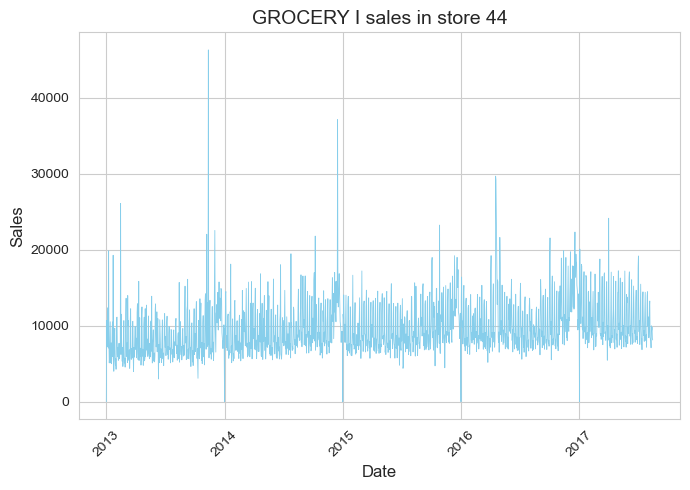

In [316]:
t_df = cross_section(df, 44, 'GROCERY I')
my_plot('GROCERY I sales in store 44', t_df['sales'], 'skyblue',0.6)

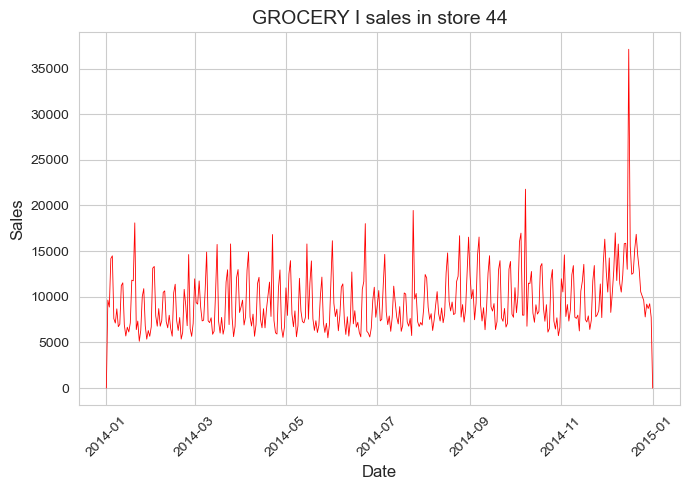

In [343]:
t_df = cross_section(df, 44, 'GROCERY I')
my_plot('GROCERY I sales in store 44', t_df.loc['2014-01-01':'2015-01-01', 'sales'], 'red',0.6)

Based on this, we can see there is a seasonality that repeats through the year and a spike happening near the end of the year (hitting a 0 sales on new years day). Sales also seem to have been growing over the years. Next lets understand the transactions df

In [346]:
#import the number of transactions for the store
df2 = datasets[names_datasets[6]]
df2['date'] = pd.to_datetime(df2['date'])

In [156]:
df2.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [350]:
len(df2['store_nbr'].unique())

54

In [198]:
#identify missing dates
all_dates = pd.date_range(start=df2.date.min(), end=df.date.max())
all_dates.difference(df2['date'])

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-01-01',
               '2016-01-03', '2016-12-25'],
              dtype='datetime64[ns]', freq=None)

In [390]:
all_dates.difference(df1['date'])

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

Based on this, it looks like the dates with missing transactions are the christmas days 2013, 2014, 2015 and 2016. It also looks like the Jan missing dates are incorrect. We will join both dfs and fill the missing values with 0

In [393]:
df.head()

id  sales  onpromotion
store_nbr family     date                                
1         AUTOMOTIVE 2013-01-01     0    0.0            0
                     2013-01-02  1782    2.0            0
                     2013-01-03  3564    3.0            0
                     2013-01-04  5346    3.0            0
                     2013-01-05  7128    5.0            0

In [461]:
#merge datasets
df = pd.merge(df, df2.set_index(['store_nbr','date']), left_index = True, right_index = True, how='left')

In [475]:
#fill NA transactions
df['transactions'] = df['transactions'].fillna(0)

In [477]:
idx = pd.IndexSlice
df.loc[idx[:, :, '2013-01-03'], :]

id    sales  onpromotion  \
store_nbr family                     date                                     
1         AUTOMOTIVE                 2013-01-03  3564    3.000            0   
          BABY CARE                  2013-01-03  3565    0.000            0   
          BEAUTY                     2013-01-03  3566    0.000            0   
          BEVERAGES                  2013-01-03  3567  919.000            0   
          BOOKS                      2013-01-03  3568    0.000            0   
...                                               ...      ...          ...   
54        POULTRY                    2013-01-03  5209    4.313            0   
          PREPARED FOODS             2013-01-03  5210    1.000            0   
          PRODUCE                    2013-01-03  5211    0.000            0   
          SCHOOL AND OFFICE SUPPLIES 2013-01-03  5212    0.000            0   
          SEAFOOD                    2013-01-03  5213    2.000            0   

                                                 transactions  
store_nbr family                     date                      
1         AUTOMOTIVE                 2013-01-03        1833.0  
          BABY CARE                  2013-01-03        1833.0  
          BEAUTY                     2013-01-03        1833.0  
          BEVERAGES                  2013-01-03        1833.0  
          BOOKS                      2013-01-03        1833.0  
...                                                       ...  
54        POULTRY                    2013-01-03         920.0  
          PREPARED FOODS             2013-01-03         920.0  
          PRODUCE                    2013-01-03         920.0  
          SCHOOL AND OFFICE SUPPLIES 2013-01-03         920.0  
          SEAFOOD                    2013-01-03         920.0  

[1782 rows x 4 columns]

As we can see, the transactions are repeated for all the same store and dates. now we can continue with the store information.

In [485]:
#import the store information 
df2 = datasets[names_datasets[3]]

In [483]:
df2.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


<Axes: xlabel='type', ylabel='cluster'>

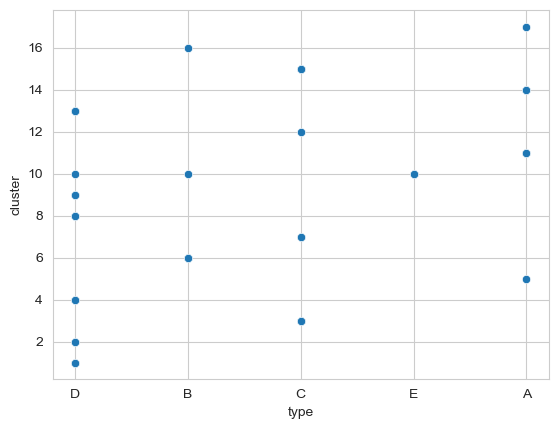

In [487]:
sns.scatterplot(df2, x='type', y='cluster')

<Axes: xlabel='type', ylabel='Count'>

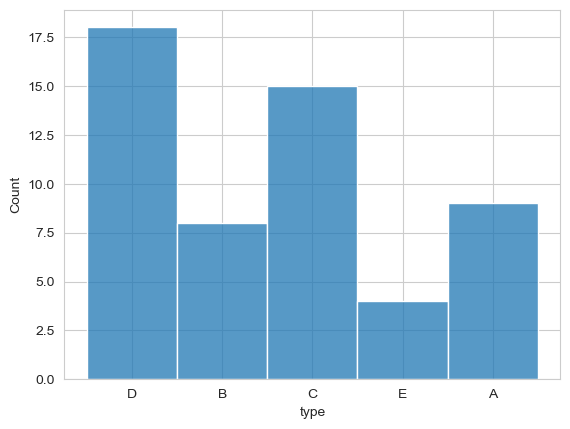

In [489]:
sns.histplot(df2['type'])

<Axes: xlabel='cluster', ylabel='Count'>

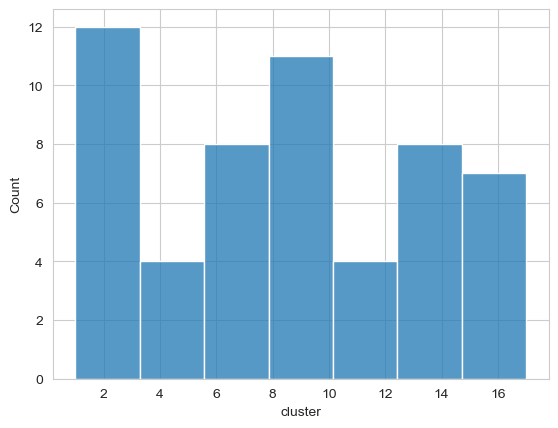

In [491]:
sns.histplot(df2['cluster'])

As we can see, it looks like the store type and cluster are not necessarily related and they both bring important information for the analysis. considering this we will import both

In [496]:
#merge on the index
df = pd.merge(df, df2.set_index(['store_nbr']), left_index = True, right_index = True, how='left')

In [498]:
df.isna().sum()

id              0
sales           0
onpromotion     0
transactions    0
city            0
state           0
type            0
cluster         0
dtype: int64

In [534]:
t_df = df.groupby('store_nbr')[['sales', 'cluster', 'type']].agg({'sales':'sum', 'cluster':'max','type':'max'})

<Axes: xlabel='cluster', ylabel='sales'>

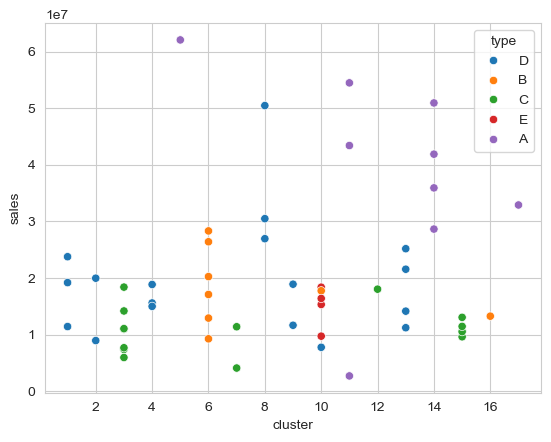

In [536]:
sns.scatterplot(t_df, x='cluster', y='sales', hue='type')

From the previous graph, we can tell taht there is some relationship between the sales, type and clusters. because of this we will keep all of them. Now we can continue with the holiday events:

In [543]:
#import the holiday information 
df2 = datasets[names_datasets[0]]
df2['date'] = pd.to_datetime(df2['date'])

In [579]:
df2[df2['transferred']].head()

,date,type,locale,locale_name,description,transferred
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
255,2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
266,2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True


In [571]:
df2[(df2['date']>'2014-10-01') & (df2['date']<'2014-10-15')]

,date,type,locale,locale_name,description,transferred
134,2014-10-07,Holiday,Local,Quevedo,Cantonizacion de Quevedo,False
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
136,2014-10-10,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False


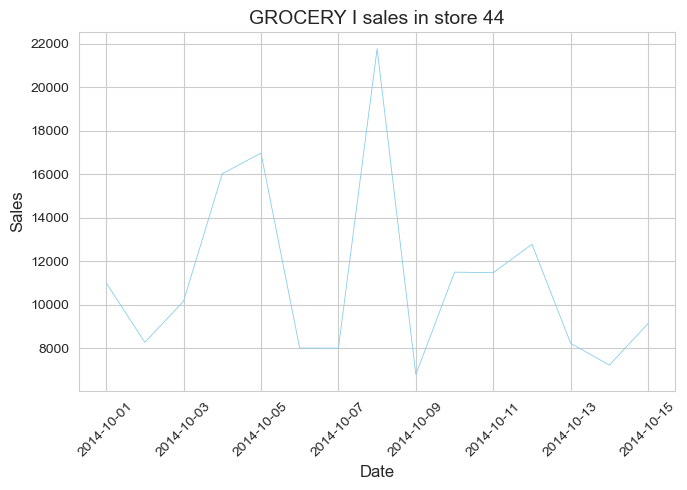

In [577]:
t_df = cross_section(df, 44, 'GROCERY I')
my_plot('GROCERY I sales in store 44', t_df.loc['2014-10-01':'2014-10-15','sales'], 'skyblue',0.6)

Based on these prelim results, it looks like the non transferred and transferred dates both add value to the analysis. We will keep both.

In [590]:
df2.set_index('date')

,type,locale,locale_name,description,transferred
date,,,,,
2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...
2017-12-22,Additional,National,Ecuador,Navidad-3,False
2017-12-23,Additional,National,Ecuador,Navidad-2,False
2017-12-24,Additional,National,Ecuador,Navidad-1,False


In [ ]:
pd.merge(df, df2.set_index(['store_nbr']), left_index = True, right_index = True, how='left')

In [596]:
df.head()

id  sales  onpromotion  transactions  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2013-01-01     0    0.0            0           0.0   
                     2013-01-02  1782    2.0            0        2111.0   
                     2013-01-03  3564    3.0            0        1833.0   
                     2013-01-04  5346    3.0            0        1863.0   
                     2013-01-05  7128    5.0            0        1509.0   

                                  city      state type  cluster  
store_nbr family     date                                        
1         AUTOMOTIVE 2013-01-01  Quito  Pichincha    D       13  
                     2013-01-02  Quito  Pichincha    D       13  
                     2013-01-03  Quito  Pichincha    D       13  
                     2013-01-04  Quito  Pichincha    D       13  
                     2013-01-05  Quito  Pichincha    D       13

In [602]:
df2['date'].value_counts()

date
2014-06-25    4
2017-06-25    3
2016-06-25    3
2015-06-25    3
2013-06-25    3
             ..
2014-07-13    1
2014-07-12    1
2014-07-09    1
2014-07-08    1
2017-12-26    1
Name: count, Length: 312, dtype: int64

In [604]:
df2[df2['date']=='2014-06-25']

,date,type,locale,locale_name,description,transferred
110,2014-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
111,2014-06-25,Holiday,Local,Machala,Fundacion de Machala,False
112,2014-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
113,2014-06-25,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Francia,False


In [606]:
df.head()

id  sales  onpromotion  transactions  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2013-01-01     0    0.0            0           0.0   
                     2013-01-02  1782    2.0            0        2111.0   
                     2013-01-03  3564    3.0            0        1833.0   
                     2013-01-04  5346    3.0            0        1863.0   
                     2013-01-05  7128    5.0            0        1509.0   

                                  city      state type  cluster  
store_nbr family     date                                        
1         AUTOMOTIVE 2013-01-01  Quito  Pichincha    D       13  
                     2013-01-02  Quito  Pichincha    D       13  
                     2013-01-03  Quito  Pichincha    D       13  
                     2013-01-04  Quito  Pichincha    D       13  
                     2013-01-05  Quito  Pichincha    D       13

In [594]:
pd.merge(df, df2.set_index(['date']), left_index=True, right_index=True, how='left')

NotImplementedError: Index._join_level on non-unique index is not implemented

In [421]:
cross_section(dft, 44, 'GROCERY I').head()

,id,sales,onpromotion,transactions
date,,,,
2013-01-01,1266,0.0,0,NaN
2013-01-02,3048,10686.0,0,4821.0
2013-01-03,4830,7342.0,0,3618.0
2013-01-04,6612,7250.0,0,4169.0
2013-01-05,8394,10699.0,0,4921.0


In [134]:
#join the transactions dataset to the train dataset 
df = pd.merge(df, df2, on=['date', 'store_nbr'],how='left')

In [136]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,NaN


In [30]:
len(df[df['transactions'].isna()].date.unique())/len(df.date.unique())

0.9299287410926366

In [150]:
#confirm if the lack of trnasactions leads to 0 sales
df[df['transactions'].isna()][['sales', 'onpromotion']].describe()

,sales,onpromotion
count,245784.000000,245784.000000
mean,9.691574,0.021633
std,234.503322,0.729582
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,19988.629000,77.000000


In [154]:
df[df['transactions'].isna() & df['sales'] > 0]

,id,date,store_nbr,family,sales,onpromotion,transactions
301191,301191,2013-06-19,10,AUTOMOTIVE,3.000,0,NaN
301194,301194,2013-06-19,10,BEVERAGES,515.000,0,NaN
301196,301196,2013-06-19,10,BREAD/BAKERY,94.000,0,NaN
301198,301198,2013-06-19,10,CLEANING,695.000,0,NaN
301199,301199,2013-06-19,10,DAIRY,43.000,0,NaN
...,...,...,...,...,...,...,...
2428794,2428794,2016-09-27,7,PLAYERS AND ELECTRONICS,12.000,0,NaN
2428795,2428795,2016-09-27,7,POULTRY,674.468,0,NaN
2428796,2428796,2016-09-27,7,PREPARED FOODS,172.204,0,NaN
2428797,2428797,2016-09-27,7,PRODUCE,5306.265,1,NaN


Considering that almost 93% of the dates have some sort of missing transactions. we will fill the missing transactions with 0 and likely will drop them as they might not bring value to the model

In [32]:
#fill nas with 0
df.transactions = df.transactions.fillna(0)

Now we will merge the store information dataset to the main df

In [39]:
df1 = datasets[names_datasets[3]]

In [41]:
pd.pivot_table(df1, index='cluster', columns='type', values='store_nbr', aggfunc='count', fill_value=0)

type,A,B,C,D,E
cluster,,,,,
1,0,0,0,3,0
2,0,0,0,2,0
3,0,0,7,0,0
4,0,0,0,3,0
5,1,0,0,0,0
6,0,6,0,0,0
7,0,0,2,0,0
8,0,0,0,3,0
9,0,0,0,2,0


Considering that the same type can be in multiple clusters, is important to keep both.

In [43]:
#join the transactions dataset to the train dataset 
df = pd.merge(df, df1, on=['store_nbr'],how='left')

Now we will merge the oil dataset with the oil prices

In [48]:
df1 = datasets[names_datasets[1]]

In [50]:
#conver to datetime
df1.date = pd.to_datetime(df1.date)

In [52]:
#join the oil dataset to the main dataset
df = pd.merge(df, df1, on=['date'],how='left')

In [54]:
#fill nas with future values
df['dcoilwtico']=df['dcoilwtico'].bfill()

Finally we will join the holidays dataset

In [59]:
df1 = datasets[names_datasets[0]]

In [61]:
#conver to datetime
df1.date = pd.to_datetime(df1.date)

Before we join the holiday dataset, we need to udnerstand that the transferred column indicates A holiday that is transferred officially falls on that calendar day, but was moved to another date by the government. A transferred day is more like a normal day than a holiday. Because of this, we will only add the actual (non transferred holidays)

In [63]:
#join the holiday dataset to the main dataset
df = pd.merge(df, df1[df1['transferred']==False], on=['date'],how='left',suffixes=('_store', '_holiday'))

In [65]:
df.isna().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
transactions          0
city                  0
state                 0
type_store            0
cluster               0
dcoilwtico            0
type_holiday    2567862
locale          2567862
locale_name     2567862
description     2567862
transferred     2567862
dtype: int64

it looks like the NA holidays are when there is no holidays and the non nas is when there was a holiday. in order to maintain a usable dataset we are fill the type and locale to "no holiday" and drop the type, locale, description and transferred.

In [67]:
#create the column for is holiday 
df['is_holiday'] = (~df['type_holiday'].isna()).astype(int)
#fill out the NA with "Ecuador" for locale_name
df['locale_name'] = df['locale_name'].fillna('Ecuador')

In [69]:
#drop the columns we will not use
df = df.drop(columns=['type_holiday', 'locale', 'locale_name', 'description', 'transferred'])

In [103]:
len(df)

3054348

In [87]:
names_datasets

['holidays_events',
 'oil',
 'sample_submission',
 'stores',
 'test',
 'train',
 'transactions']

In [101]:
(datasets[names_datasets[-3]])

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9


In [83]:
len(datasets[names_datasets[5]])

3000888

Now, we understand that the transactions AS expected, the number of sales is lower than the number of transactions in most cases. this due to the fact that many transactions could be for far less than 1 dollar. We will forecast the number of sales after all 

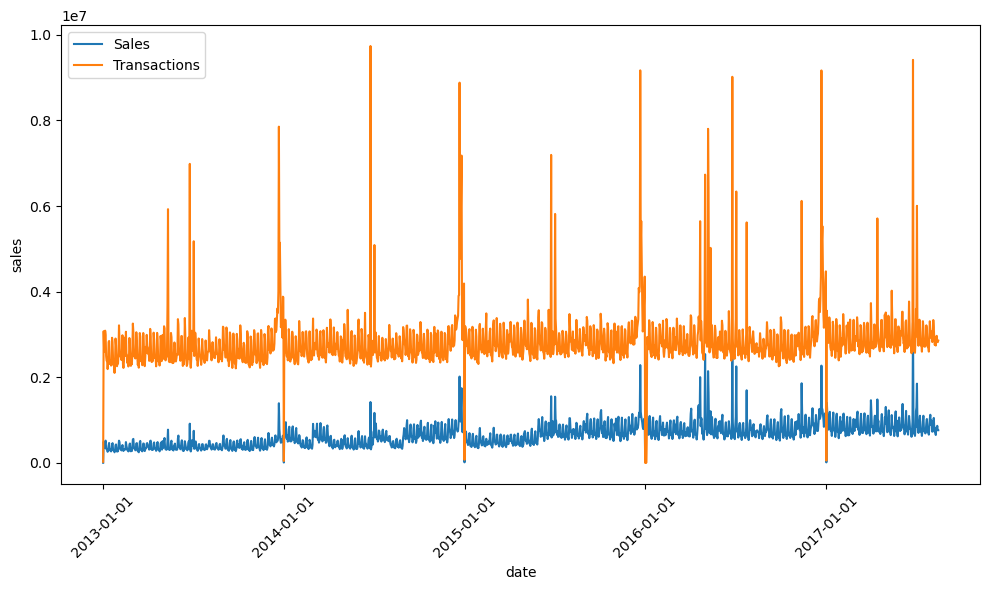

In [75]:
fig, ax = plt.subplots(figsize=(10, 6))
df1 = df[['date', 'sales', 'transactions']].groupby('date').sum()
sns.lineplot(df1['sales'], ax=ax, label = 'Sales')
sns.lineplot(df1['transactions'], ax=ax , label = 'Transactions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df1 = df1.drop(columns = 'transactions')

In [ ]:
df.head()

Identify if there is a seasonality first:

In [ ]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df['#Passengers'])

Considering the above, it looks like there is a seasonality that repeats every 12 lags or so. Lets identify the ACF and PACF:

In [ ]:
import statsmodels.api as sm
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['#Passengers'], lags=12, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['#Passengers'], lags=12, ax=ax2)

ACF plots show the correlation between a time series and a lagged version of itself, decreasing exponentially. 

PACF plots show the correlation between a time series and a lagged version of itself after removing the effects of intervening observations. The PACF graph is abrupt after 2 views.

the next thing we need to do es identify the decomposition parts:

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['#Passengers'], period=12)  
fig = plt.figure()  
fig = decomposition.plot()  
fig.set_size_inches(15, 8)

In [ ]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window=52).mean()
    rolstd = timeseries.rolling(window=52).std()

    #Plot rolling statistics:
    fig = plt.figure(figsize=(12, 8))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()
    
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

In [ ]:
test_stationarity(df['#Passengers'])

Since the results are showing the data is not stationary, we need to make it stationary by either differencing, log, square, cube root or proportional change

In [ ]:
df_firstdiff = df['#Passengers'].diff(12) #taking the first difference
test_stationarity(df_firstdiff.dropna()) #testing the data to identify if it is stationary now

Now that the data is stationary, we can identify the p, d and q values to use for ARIMa. in order to do so we are going to use auto ARIMA

In [ ]:
df['month_index']= df.index.month

In [ ]:
import pmdarima as pmd

model=pmd.auto_arima(df['#Passengers'], exogenous = df['month_index'], 
                        start_p=1, start_q=1, test='adf',
                        max_p=3, max_q=3, m=12,
                        start_P=0, seasonal=True,
                        d=None, D=1, trace=True, error_action='ignore',
                        suppress_warnings=True, stepwise=True)

In [ ]:
display(model.summary())
model.plot_diagnostics(figsize=(12,6));

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
mod=SARIMAX(df['#Passengers'],order=(0,1,1),seasonal_order=(2,1,0,12))
sarima = mod.fit()
predicted=sarima.predict();predicted

We are looking for: 
<ul>
    <li>P > |z| (p-value) < 0.05</li>
    <li>Prob(Q) > 0.05 --> residues are white noise</li>
    <li>Prob(JB) > 0.05 residues normally distributed</li>
    <li>Prob(H) > 0.05 variance of residuals is constant over time</li>
</ul>


In [ ]:
df['pred'] = predicted

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(df, x='Month', y='#Passengers', ax=ax, color='blue')
sns.lineplot(df, x='Month', y='pred', ax=ax, color='red')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Now, for future forecast. we will create the funciton that takes the trained model and generates 2 years (24 months) of forecast:

In [ ]:
def sarimax_forecast(SARIMAX_model, periods=24):
    # Forecast
    n_periods = periods

    forecast_df = pd.DataFrame({"month_index": pd.date_range(df.index[-1], periods=n_periods, freq='MS').month},
                               index=pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS'))

    fcst = SARIMAX_model.get_forecast(steps=n_periods,
                                            exog=forecast_df['month_index'])
    fitted = fcst.predicted_mean
    confint = fcst.conf_int(alpha = 0.05)

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=fitted.index)
    lower_series = pd.Series(confint.iloc[:, 0], index=confint.index)
    upper_series = pd.Series(confint.iloc[:, 1], index=confint.index)

    # Plot
    plt.figure(figsize=(15, 7))
    plt.plot(df["#Passengers"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                     lower_series,
                     upper_series,
                     color='k', alpha=.15)

    plt.title("SARIMAX - Forecast of Airline Passengers")
    plt.show()

In [ ]:
sarimax_forecast(sarima, 24)